In [9]:
#########################
# Include Headers
#########################

using LinearAlgebra
using HDF5
using Arpack
using CairoMakie
using StatsBase

include("../.header/.src/circuit/brickwall.jl")
include("../.header/.src/circuit/heisenberg.jl")
#include("../header/.src/circuit/time-crystals.jl")
include("../.header/.src/hdf5/hdf5_mods.jl")
include("../.header/.src/plotmods/colorschemes_mods.jl")

include("../.header/.src/eigen_statistics/eigen_statistics.jl")
include("../.header/.src/functions/histgram.jl")

include("../.header/.src/random_matrices/random_matrices.jl")
include("../.header/.src/measurements/projectors.jl")
include("../.header/.src/info_lattice/info_lattice.jl")
include("../.header/.src/lazadires_diagram/lazadires_diagram.jl")


In [66]:
#### Mean LevelSpacingRatio

tun_par=thetalist=[collect(0.0:0.025:0.525); collect(0.6:0.05:1.6)]
Xind=length(tun_par)

L=10
Itrnumb=10

  file=h5open("../data/hiesenberg_transition_ordpar_L$(L).hdf5","r")

#file_dest=h5open("../data/hiesenberg_transition_ordpar.hdf5","cw")



ord_par=fill(0.0, Xind)
for i in 1:Xind
   theta=tun_par[i]
   for itr in 1:Itrnumb
   ord_par[i]+=mean(LevelSpacingRatio(file["L$(L)/theta$(theta)/Itr$(itr)/eigvals"][:]))
   end
end
ord_par_heis_10=ord_par/Itrnumb

#file_dest["L$(L)/MeanLevelSpacingRatio"]=ord_par;
#attrs=attributes(file_dest["L$(L)/MeanLevelSpacingRatio"])
#atts["Itrnumb"]=Itrnumb

close(file)
#close(file_dest)



┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Ritam\.julia\packages\Makie\4JW9B\src\scenes.jl:264


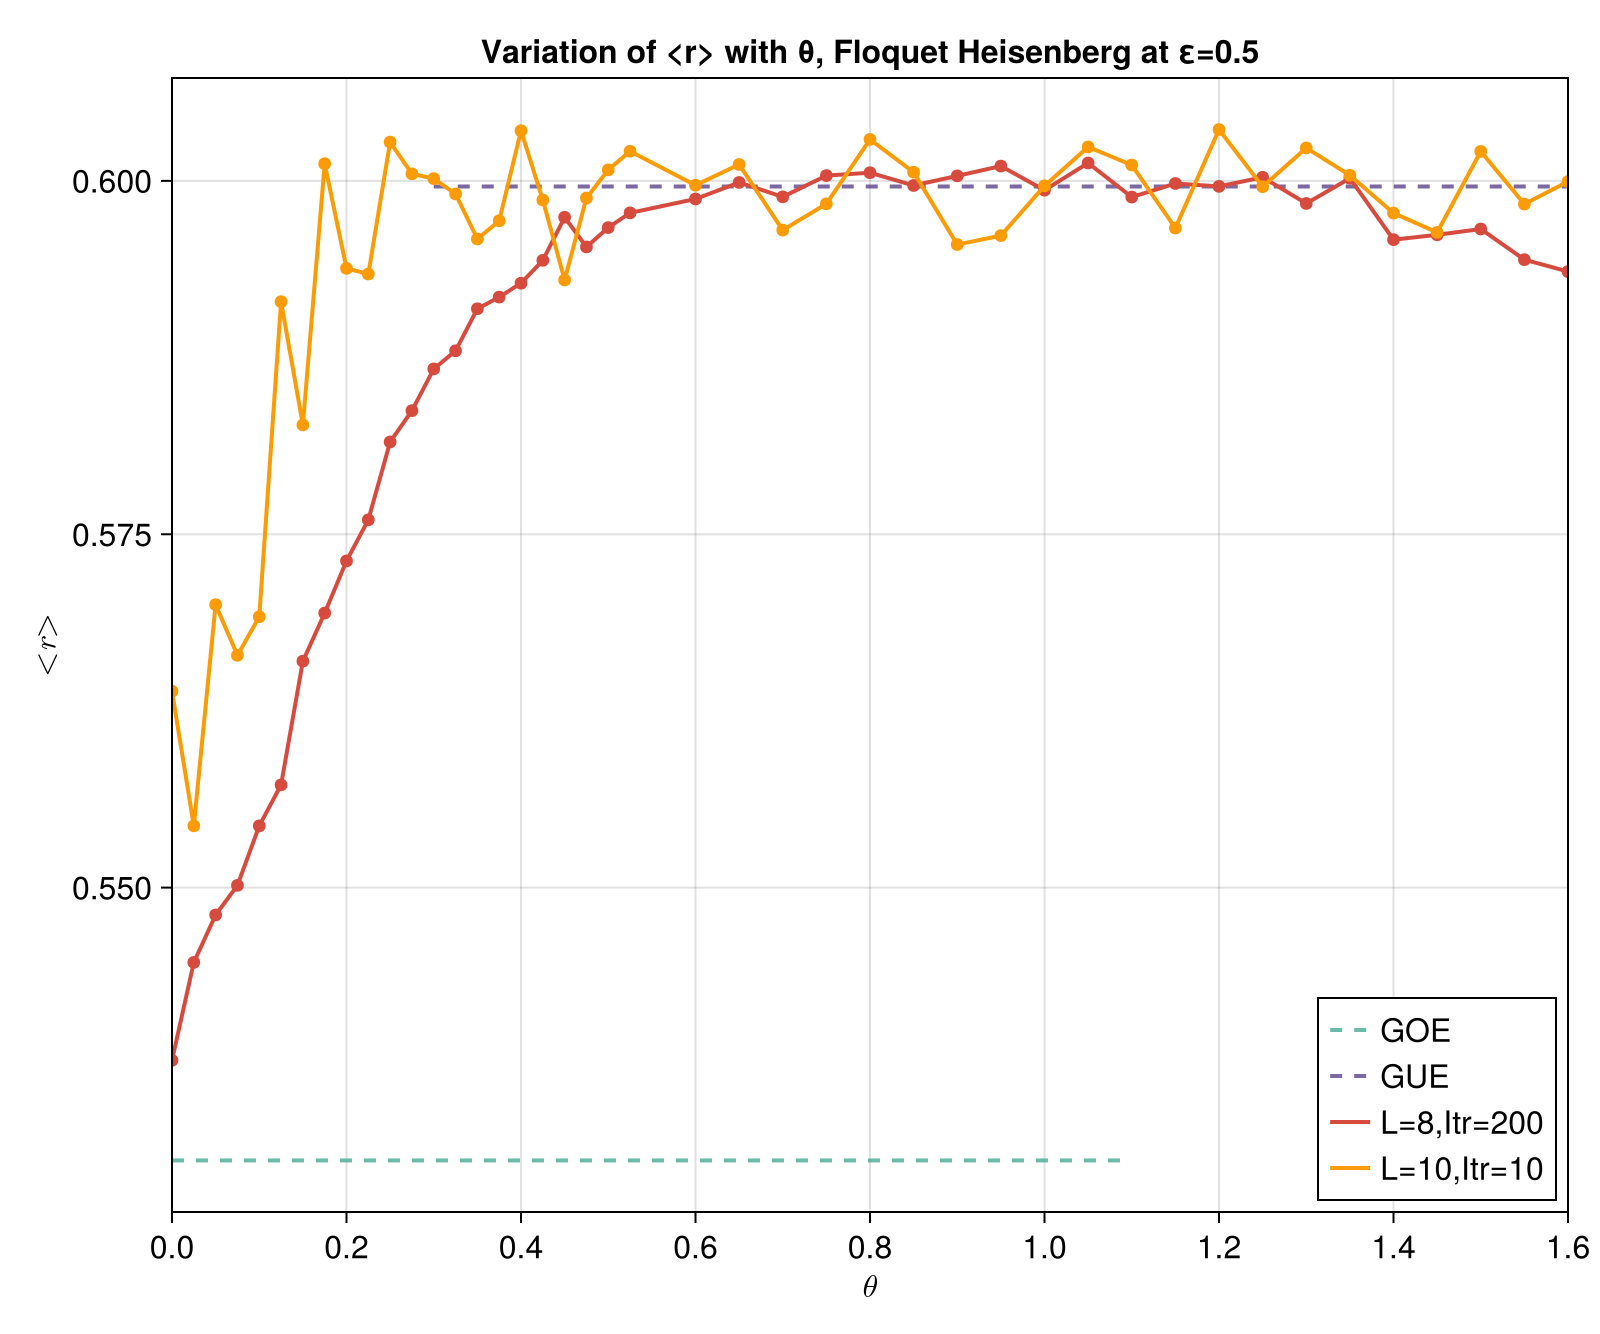

In [77]:
###############################
# Variation of <r> with theta  
###############################
    
# Desired aspect ratio
aspect_ratio = 6/5

# Set the figure width (for example, 800 pixels)
fig_width = 800
fig_height = fig_width / aspect_ratio
fig = Figure(resolution = (fig_width, fig_height), fontsize=16)


ax=Axis(fig[1,1],xlabel = L"$\theta$",          #Label for X  
ylabel = L"$<r>$",         #Label for Y
title = "Variation of <r> with θ, Floquet Heisenberg at ε=0.5")#,      #Plot Title
#xticks = (0.0:0.01:0.65),                #Xticks
#yticks = (0.3:0.05:0.6) )

xlims!(ax, (tun_par[1], tun_par[end]))

    xs = tun_par              
    #ys = ord_par

    #xs_poission=collect(0.0:0.1:0.9)
    xs_goe=collect(0.0:0.1:1.15)
    xs_gue=collect(0.3:0.1:1.6)
    #ys = ord_par




    #CairoMakie.lines!(ax, xs_poission, fill(0.38629, length(xs_poission)), color=(viridis[7],0.85),linestyle=:dash, label="Poission", linewidth=2)
    CairoMakie.lines!(ax, xs_goe, fill(0.53070, length(xs_goe)), color=(viridis[18],0.7),linestyle=:dash, label="GOE", linewidth=2)
    CairoMakie.lines!(ax, xs_gue, fill(0.5996, length(xs_gue)), color=(viridis[45],0.7),linestyle=:dash, label="GUE", linewidth=2)
 




    #The Heatmap
    CairoMakie.lines!(ax, xs, ord_par_heis_8, color=inferno[22], label="L=8,Itr=200", linewidth=2)
    CairoMakie.scatter!(ax, xs, ord_par_heis_8, color=inferno[22])

    CairoMakie.lines!(ax, xs, ord_par_heis_10, color=inferno[12], label="L=10,Itr=10", linewidth=2)
    CairoMakie.scatter!(ax, xs, ord_par_heis_10, color=inferno[12])
                                                             
                                                             
   #Colorbar(fig[1,2],                        #Colorbar
   #              ticks = 0.0:0.1:1.0)            #Colorbar ticks
    
   axislegend(ax, position=:rb)

      save("../../tex/.src/images/levelspacing_vertical_heisenberg.png", fig)
    fig
    

In [ ]:
Poisson            = 0.38629
GOE (β=1)          = 0.53070
GUE (β=2)          = 0.60266
GSE (β=4)          = 0.67617
Semi-Poisson       ≈ 0.5 (but not universal)
β-ensemble (gen.)  = via formula above


In [4]:
#### Mean LevelSpacingRatio

tun_par=thetalist=[collect(0.0:0.025:0.525); collect(0.6:0.05:1.6)]
Xind=length(tun_par)

L=8
Itrnumb=100

  file=h5open("../data/dtc_vertical_transition_ordpar_L$(L).hdf5","r")

#file_dest=h5open("../data/hiesenberg_transition_ordpar.hdf5","cw")



ord_par=fill(0.0, Xind)
for i in 1:Xind
   theta=tun_par[i]
   for itr in 1:Itrnumb
   ord_par[i]+=mean(LevelSpacingRatio(file["L$(L)/theta$(theta)/Itr$(itr)/eigvals"][:]))
   end
end
ord_par_dtc_8=ord_par/Itrnumb

#file_dest["L$(L)/MeanLevelSpacingRatio"]=ord_par;
#attrs=attributes(file_dest["L$(L)/MeanLevelSpacingRatio"])
#atts["Itrnumb"]=Itrnumb

close(file)
#close(file_dest)



┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Ritam\.julia\packages\Makie\4JW9B\src\scenes.jl:264


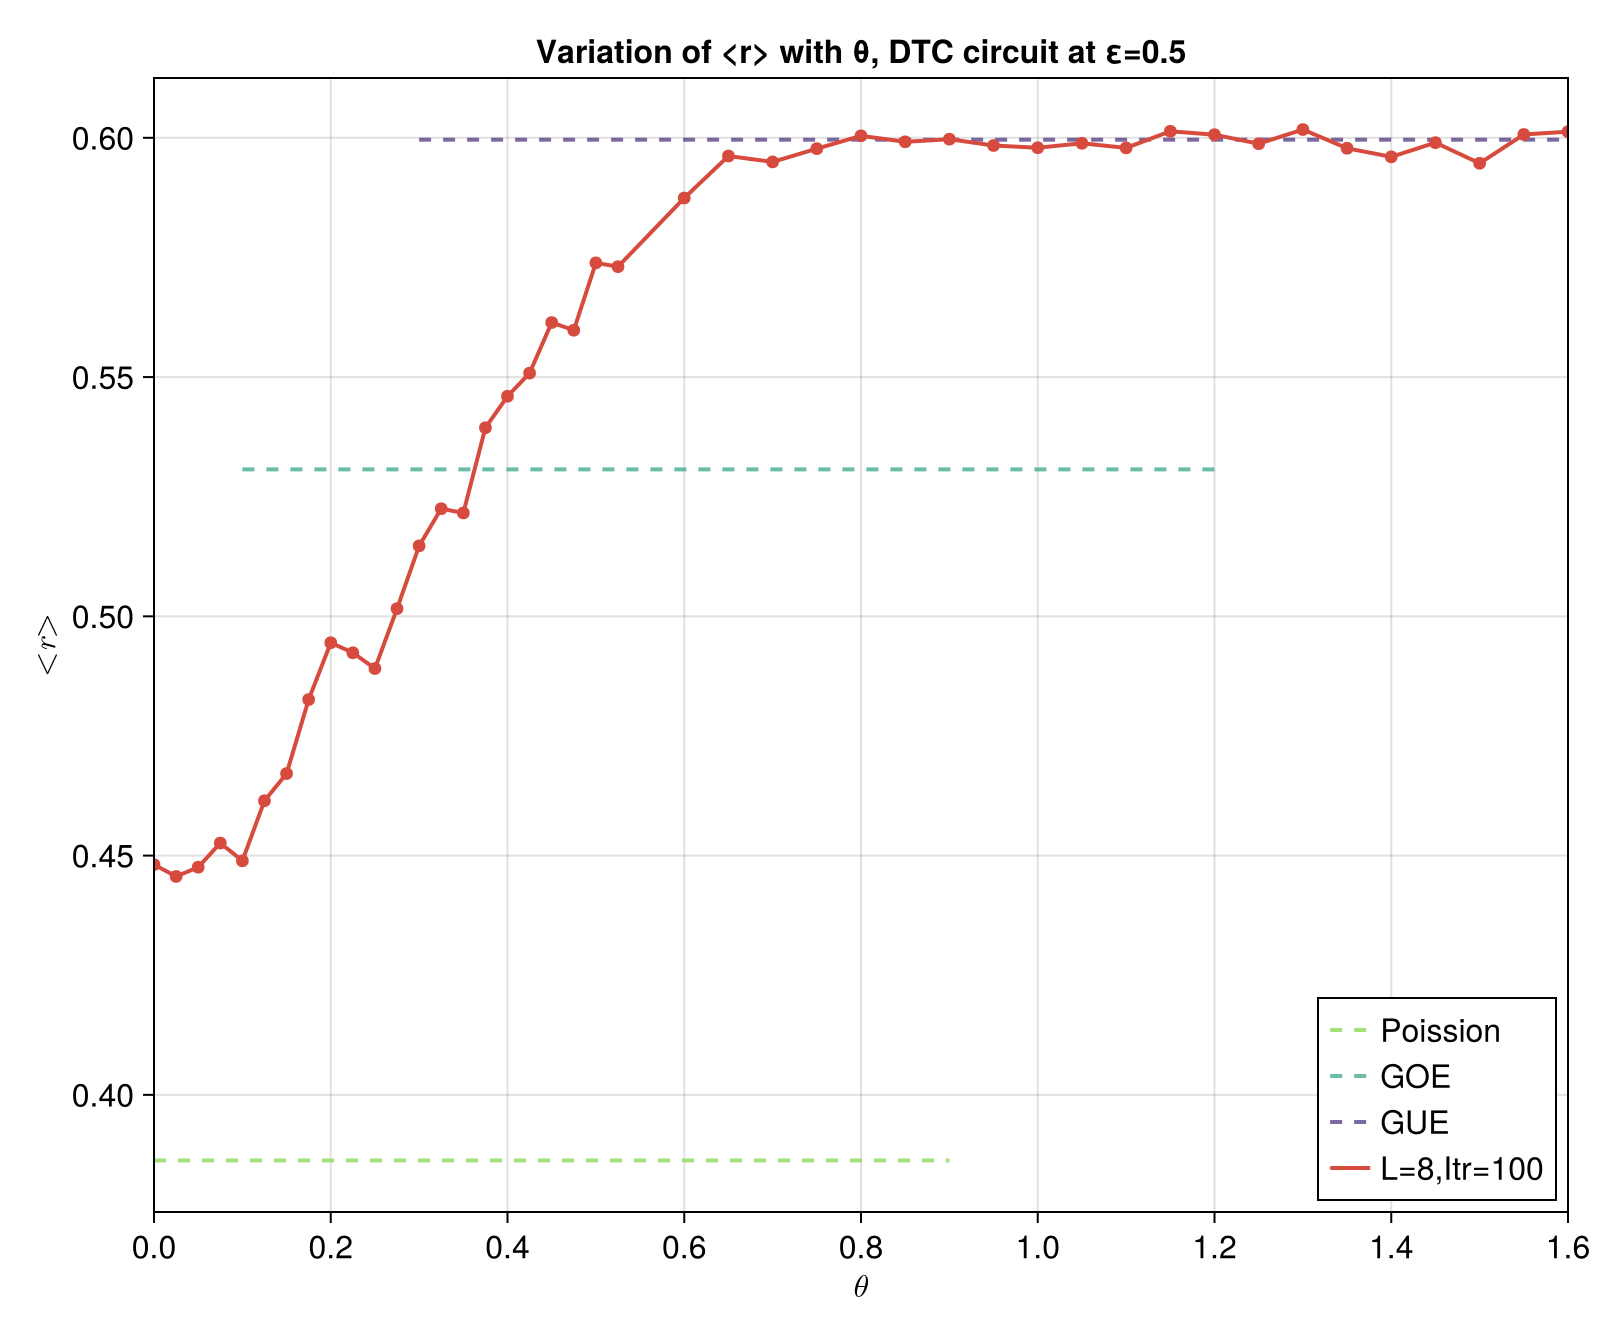

In [5]:
###############################
# Variation of <r> with theta  
###############################
    
# Desired aspect ratio
aspect_ratio = 6/5

# Set the figure width (for example, 800 pixels)
fig_width = 800
fig_height = fig_width / aspect_ratio
fig = Figure(resolution = (fig_width, fig_height), fontsize=16)


ax=Axis(fig[1,1],xlabel = L"$\theta$",          #Label for X  
ylabel = L"$<r>$",         #Label for Y
title = "Variation of <r> with θ, DTC circuit at ε=0.5")#,      #Plot Title
#xticks = (0.0:0.01:0.65),                #Xticks
#yticks = (0.3:0.05:0.6) )

xlims!(ax, (tun_par[1], tun_par[end]))

    xs = tun_par              

    xs_poission=collect(0.0:0.1:0.9)
    xs_goe=collect(0.1:0.1:1.2)
    xs_gue=collect(0.3:0.1:1.6)
    #ys = ord_par




    CairoMakie.lines!(ax, xs_poission, fill(0.38629, length(xs_poission)), color=(viridis[7],0.85),linestyle=:dash, label="Poission", linewidth=2)
    CairoMakie.lines!(ax, xs_goe, fill(0.53070, length(xs_goe)), color=(viridis[18],0.7),linestyle=:dash, label="GOE", linewidth=2)
    CairoMakie.lines!(ax, xs_gue, fill(0.5996, length(xs_gue)), color=(viridis[45],0.7),linestyle=:dash, label="GUE", linewidth=2)
 

    #The Heatmap
    CairoMakie.lines!(ax, xs, ord_par_dtc_8, color=inferno[22], label="L=8,Itr=100", linewidth=2)
    CairoMakie.scatter!(ax, xs, ord_par_dtc_8, color=inferno[22])
                                                             
   #Colorbar(fig[1,2],                        #Colorbar
   #              ticks = 0.0:0.1:1.0)            #Colorbar ticks
    
   axislegend(ax, position=:rb)

   save("../../tex/.src/images/levelspacing_vertical_timecrystal.png", fig)
   fig
    

In [13]:
#### Mean LevelSpacingRatio

tun_par=thetalist=[collect(0.0:0.025:0.525); collect(0.6:0.05:1.6)]
Xind=length(tun_par)

L=8
Itrnumb=100

  file=h5open("../data/hiesenberg_transition_ordpar_clean_abanin15_L$(L).hdf5","r")

#file_dest=h5open("../data/hiesenberg_transition_ordpar.hdf5","cw")



ord_par=fill(0.0, Xind)
for i in 1:Xind
   theta=tun_par[i]
   for itr in 1:Itrnumb
   ord_par[i]+=mean(LevelSpacingRatio(file["L$(L)/theta$(theta)/Itr$(itr)/eigvals"][:]))
   end
end
ord_par_dtc_8=ord_par/Itrnumb

#file_dest["L$(L)/MeanLevelSpacingRatio"]=ord_par;
#attrs=attributes(file_dest["L$(L)/MeanLevelSpacingRatio"])
#atts["Itrnumb"]=Itrnumb

close(file)
#close(file_dest)



┌ Warning: Found `resolution` in the theme when creating a `Scene`. The `resolution` keyword for `Scene`s and `Figure`s has been deprecated. Use `Figure(; size = ...` or `Scene(; size = ...)` instead, which better reflects that this is a unitless size and not a pixel resolution. The key could also come from `set_theme!` calls or related theming functions.
└ @ Makie C:\Users\Ritam\.julia\packages\Makie\4JW9B\src\scenes.jl:264


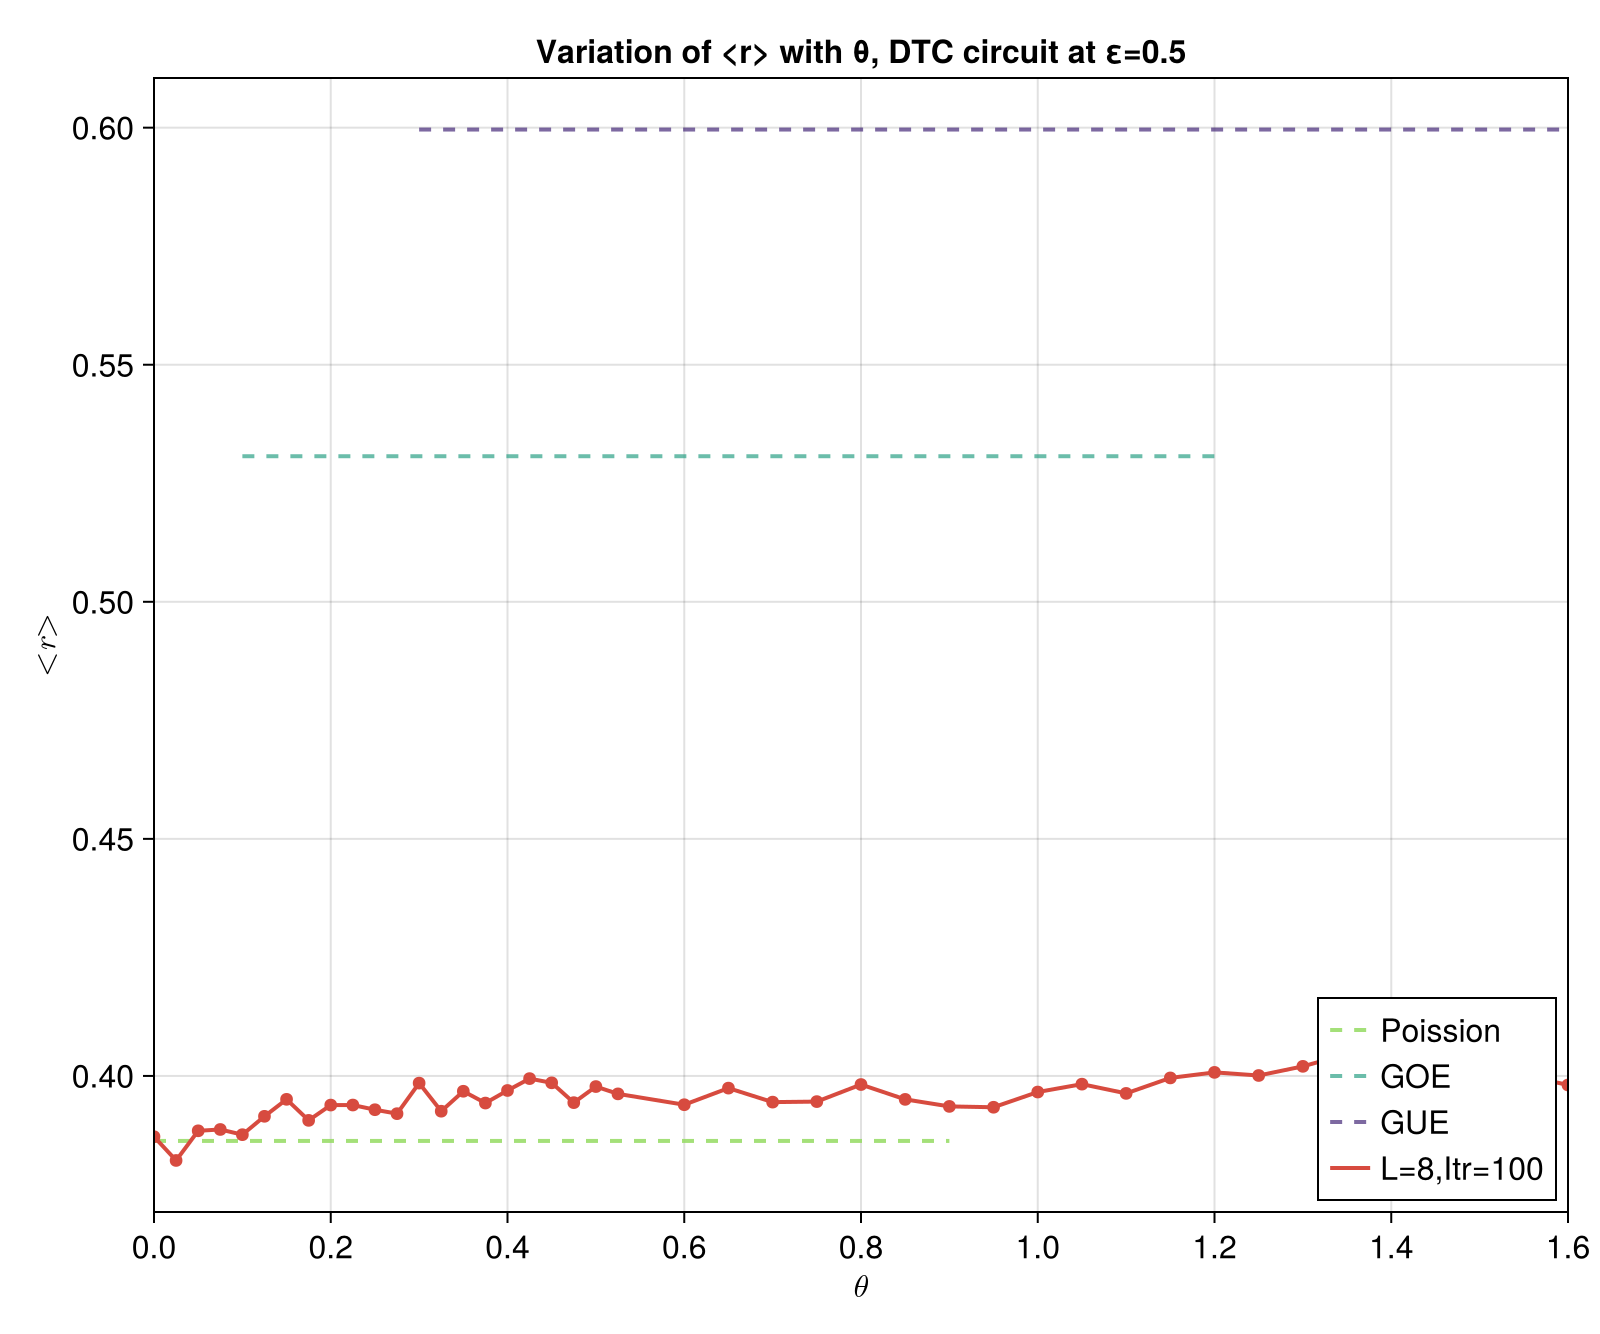

In [14]:
###############################
# Variation of <r> with theta  
###############################
    
# Desired aspect ratio
aspect_ratio = 6/5

# Set the figure width (for example, 800 pixels)
fig_width = 800
fig_height = fig_width / aspect_ratio
fig = Figure(resolution = (fig_width, fig_height), fontsize=16)


ax=Axis(fig[1,1],xlabel = L"$\theta$",          #Label for X  
ylabel = L"$<r>$",         #Label for Y
title = "Variation of <r> with θ, DTC circuit at ε=0.5")#,      #Plot Title
#xticks = (0.0:0.01:0.65),                #Xticks
#yticks = (0.3:0.05:0.6) )

xlims!(ax, (tun_par[1], tun_par[end]))

    xs = tun_par              

    xs_poission=collect(0.0:0.1:0.9)
    xs_goe=collect(0.1:0.1:1.2)
    xs_gue=collect(0.3:0.1:1.6)
    #ys = ord_par




    CairoMakie.lines!(ax, xs_poission, fill(0.38629, length(xs_poission)), color=(viridis[7],0.85),linestyle=:dash, label="Poission", linewidth=2)
    CairoMakie.lines!(ax, xs_goe, fill(0.53070, length(xs_goe)), color=(viridis[18],0.7),linestyle=:dash, label="GOE", linewidth=2)
    CairoMakie.lines!(ax, xs_gue, fill(0.5996, length(xs_gue)), color=(viridis[45],0.7),linestyle=:dash, label="GUE", linewidth=2)
 

    #The Heatmap
    CairoMakie.lines!(ax, xs, ord_par_dtc_8, color=inferno[22], label="L=8,Itr=100", linewidth=2)
    CairoMakie.scatter!(ax, xs, ord_par_dtc_8, color=inferno[22])
                                                             
   #Colorbar(fig[1,2],                        #Colorbar
   #              ticks = 0.0:0.1:1.0)            #Colorbar ticks
    
   axislegend(ax, position=:rb)

   #save("../../tex/.src/images/levelspacing_vertical_timecrystal.png", fig)
   fig
    